# 04 · B1 DataTurks + B2 SkillSpan — the extraction supervision

B1 is resume-native but tiny and defective; B2 is 10× the span volume with peer-reviewed
guidelines, but annotated on job postings. The project uses both (decision **D5**), so the
label schemes have to be reconciled — this notebook establishes what has to be reconciled.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from candidate_screener.config import DOCS_DATA, RAW, MANIFEST, PROFILE_METRICS
from candidate_screener.data.profile import load_split
from candidate_screener.data.sources import SOURCES

pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

METRICS = json.loads(PROFILE_METRICS.read_text())["checks"]
print("profile metrics generated:", json.loads(PROFILE_METRICS.read_text())["generated"])

profile metrics generated: 2026-08-19T11:50:52+00:00


## B1 — entity inventory, and the PII that is baked into the label set

220 documents, 3556 spans


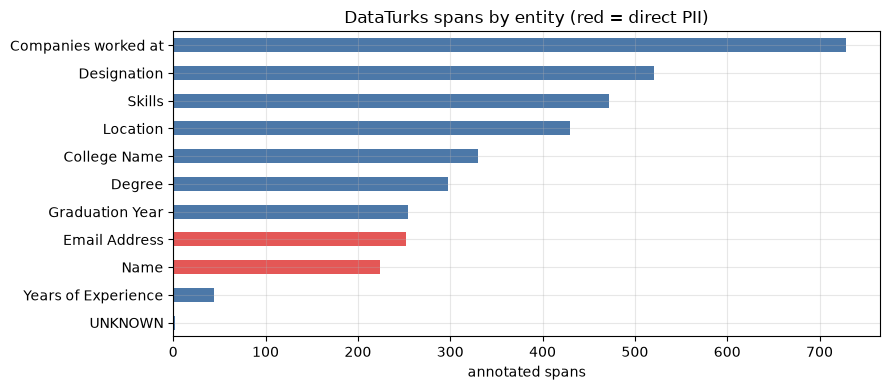

In [2]:
import re

from candidate_screener.data.profile import _load_dataturks

docs = _load_dataturks()
ents = pd.Series(METRICS["dataturks"]["entities"]).sort_values()
ax = ents.plot.barh(color=["#E45756" if k in ("Name", "Email Address") else "#4C78A8"
                           for k in ents.index])
ax.set_xlabel("annotated spans"); ax.set_title("DataTurks spans by entity (red = direct PII)")
plt.tight_layout()
print(f"{len(docs)} documents, {METRICS['dataturks']['spans']} spans")

**Skills — the project's primary entity — has only 472 spans**, and `Years of Experience`
only 44. `Name` and `Email Address` together account for 476 spans that must be stripped
before use.

## The 6.2% offset defect — this silently corrupts BIO conversion if ignored

In [3]:
broken = []
for d in docs:
    for a in d.get("annotation") or []:
        if not a or not a.get("label"):
            continue
        lab = a["label"][0] if isinstance(a["label"], list) else a["label"]
        for p in a.get("points", []):
            sliced = d["content"][p["start"]:p["end"] + 1]
            if sliced.strip() != (p.get("text") or "").strip():
                broken.append({"label": lab, "stored": (p.get("text") or "")[:40],
                               "sliced_by_offsets": sliced[:40]})
broken = pd.DataFrame(broken)
print(f"{len(broken)} broken spans ({100 * len(broken) / METRICS['dataturks']['spans']:.1f}%)")
print(broken.label.value_counts().to_dict())
broken.head(8)

222 broken spans (6.2%)
{'Skills': 40, 'College Name': 40, 'Degree': 39, 'Companies worked at': 37, 'Designation': 24, 'Location': 17, 'Graduation Year': 14, 'Email Address': 9, 'Name': 1, 'UNKNOWN': 1}


,label,stored,sliced_by_offsets
0,Skills,"Soft Skills\n\nCommunicator, Innovator, Te",TIONAL INFORMATION\n\nSoft Skills\n\nCommuni
1,Skills,"\nAdobe Photoshop (Less than 1 year), Ads",April 2014\n\nSKILLS\n\nAdobe Photoshop (Le
2,Companies worked at,"Infosys - Pune, Maharashtra -\n","ultant\n\nInfosys - Pune, Mahara"
3,Designation,Associate Consultant\n,graphy\n\nAssociate Con
4,Companies worked at,Infosys Limited,nt\n\nInfosys Lim
5,Designation,Associate Consultant\n,ior Associate Consult
6,Designation,Senior Associate Consultant,CE\n\nSenior Associate Consul
7,Email Address,indeed.com/r/Nida-Khan/6c9160696f57efd8,www.indeed.com/r/Nida-Khan/6c9160696f57


The stored `text` and the slice its offsets point at disagree — an inclusive/exclusive `end`
bug plus stray whitespace. Action plan §3.1: repair or drop every one, and log it. Silently
converting these produces BIO tags on the wrong tokens and NER scores that are wrong in a
direction nobody notices.

## Render one resume with its spans, and confirm what `Skills` actually contains

In [4]:
from IPython.display import HTML, display

COLOURS = {"Skills": "#a7f3d0", "Designation": "#bfdbfe", "Companies worked at": "#fde68a",
           "Name": "#fecaca", "Email Address": "#fecaca", "Degree": "#ddd6fe",
           "College Name": "#e9d5ff", "Location": "#fed7aa"}
REDACT = {"Name": "[NAME]", "Email Address": "[EMAIL]"}   # never render direct PII


def spans_of(doc):
    for a in doc.get("annotation") or []:
        if not a or not a.get("label"):
            continue
        lab = a["label"][0] if isinstance(a["label"], list) else a["label"]
        for p in a.get("points", []):
            yield p["start"], p["end"] + 1, lab


def render(doc, limit=1800):
    """Highlight spans, replacing the two direct-PII classes with placeholders.

    This is the de-identification of action plan 3.1 applied at display time: the
    notebook is committed with its outputs, so nothing un-redacted may reach the repo.
    """
    text = doc["content"][:limit]
    out, last = [], 0
    for s, e, lab in sorted(m for m in spans_of(doc) if m[1] <= limit):
        if s < last:
            continue
        shown = REDACT.get(lab, text[s:e])
        out.append(text[last:s])
        out.append(f"<mark style='background:{COLOURS.get(lab, '#e5e7eb')}' "
                   f"title='{lab}'>{shown}</mark>")
        last = e
    out.append(text[last:])
    body = "".join(out)
    for pattern, sub in ((r"[\w.+-]+@[\w-]+\.[\w.]+", "[EMAIL]"),
                         (r"(?:https?://|www\.)\S+|indeed\.com/\S+", "[URL]")):
        body = re.sub(pattern, sub, body)
    return "<pre style='white-space:pre-wrap;font-size:12px'>" + body + "</pre>"


display(HTML(render(docs[0])))


In [5]:
skills = [p.get("text") for d in docs for a in (d.get("annotation") or [])
          if a and a.get("label") and (a["label"][0] if isinstance(a["label"], list) else a["label"]) == "Skills"
          for p in a.get("points", [])]
lengths = pd.Series([len(s.split()) for s in skills if s])
print(f"{len(skills)} Skills spans; words per span: median={lengths.median():.0f} "
      f"mean={lengths.mean():.1f} max={lengths.max()}")
for s in skills[:3]:
    print("---", s[:300].replace("\n", " "))

472 Skills spans; words per span: median=3 mean=16.4 max=352
--- Languages: Core Java, Go Lang, Data Structures & Algorithms, Oracle PL-SQL programming, Sales Force with APEX. Tools: RADTool, Jdeveloper, NetBeans, Eclipse, SQL developer, PL/SQL Developer, WinSCP, Putty Web Technologies: JavaScript, XML, HTML, Webservice  Operating Systems: Linux, Windows Version 
--- APEX. (Less than 1 year), Data Structures (3 years), FLEXCUBE (5 years), Oracle (5 years), Algorithms (3 years) 
--- Functional Testing, Blue Prism, Qtp 


The `Skills` spans are **multi-skill blobs**, often a whole skills section, not individual
skills. They cannot be used as-is for skill-level evaluation: they need segmentation against
the ESCO vocabulary (D1) first. This is the single biggest reason B1 cannot carry the
extraction evaluation alone.

## B2 SkillSpan — the volume, on two annotation layers

In [6]:
ss = {s: load_split("skillspan", s) for s in ("train", "validation", "test")}
inv = pd.DataFrame({
    s: {"sentences": len(df), "tokens": sum(len(t) for t in df.tokens),
        "skill spans": sum(t.count("B") for t in df.tags_skill.map(list)),
        "knowledge spans": sum(t.count("B") for t in df.tags_knowledge.map(list))}
    for s, df in ss.items()})
inv["TOTAL"] = inv.sum(axis=1)
inv

,train,validation,test,TOTAL
sentences,4800,3174,3569,11543
tokens,93453,40057,42786,176296
skill spans,2221,1070,1090,4381
knowledge spans,2969,1093,1174,5236


In [7]:
df = ss["train"]
row = next(r for _, r in df.iterrows() if "B" in list(r.tags_skill))
pd.DataFrame({"token": row.tokens, "tags_skill": row.tags_skill,
              "tags_knowledge": row.tags_knowledge}).head(30).T

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
token,You,will,be,working,in,an,end-to-end,cross-functional,team,being,...,and,promoting,all,QA,relevant,topics,on,team,level,.
tags_skill,O,O,O,O,O,O,O,O,O,O,...,I,I,I,I,I,I,O,O,O,O
tags_knowledge,O,O,O,O,O,O,O,O,O,O,...,O,O,O,B,O,O,O,O,O,O


`tags_skill` (soft/behavioural) and `tags_knowledge` (hard/tools) are separate BIO layers on
the same tokens. That division maps directly onto ESCO's `skill/competence` vs `knowledge`
split (10,734 / 3,221), so **one label scheme covers both sources** — decide it once, here:

| Project label | SkillSpan layer | ESCO `skillType` | DataTurks |
|---|---|---|---|
| `SKILL` | `tags_skill` | `skill/competence` | `Skills` (after segmentation) |
| `KNOWLEDGE` / tool | `tags_knowledge` | `knowledge` | `Skills` (after segmentation) |
| `TITLE`, `ORG`, `DEGREE`, `EDU`, `YEARS` | — | — | native classes |

The domain shift is the cost: B2 is job-postings text, B1 is resume text. Report extraction
scores on the resume-native set with cross-validation over all 220 docs (§3.1) — never on the
20-document shipped test split.